Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?client_id=357496962394-k3hoomdc6ib3bi8rcij6fov7vf1rvs2g.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8080%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive&access_type=offline&response_type=code

Authentication successful.
Year =  2026.0
Month =  1.0
Day =  29.0
Latitude (degs N) =  34.1414
Longitude (degs E) =  -77.86684
Secchi depth (cm) =  1.0
Forel Ule =  0.0
pH =  19.0


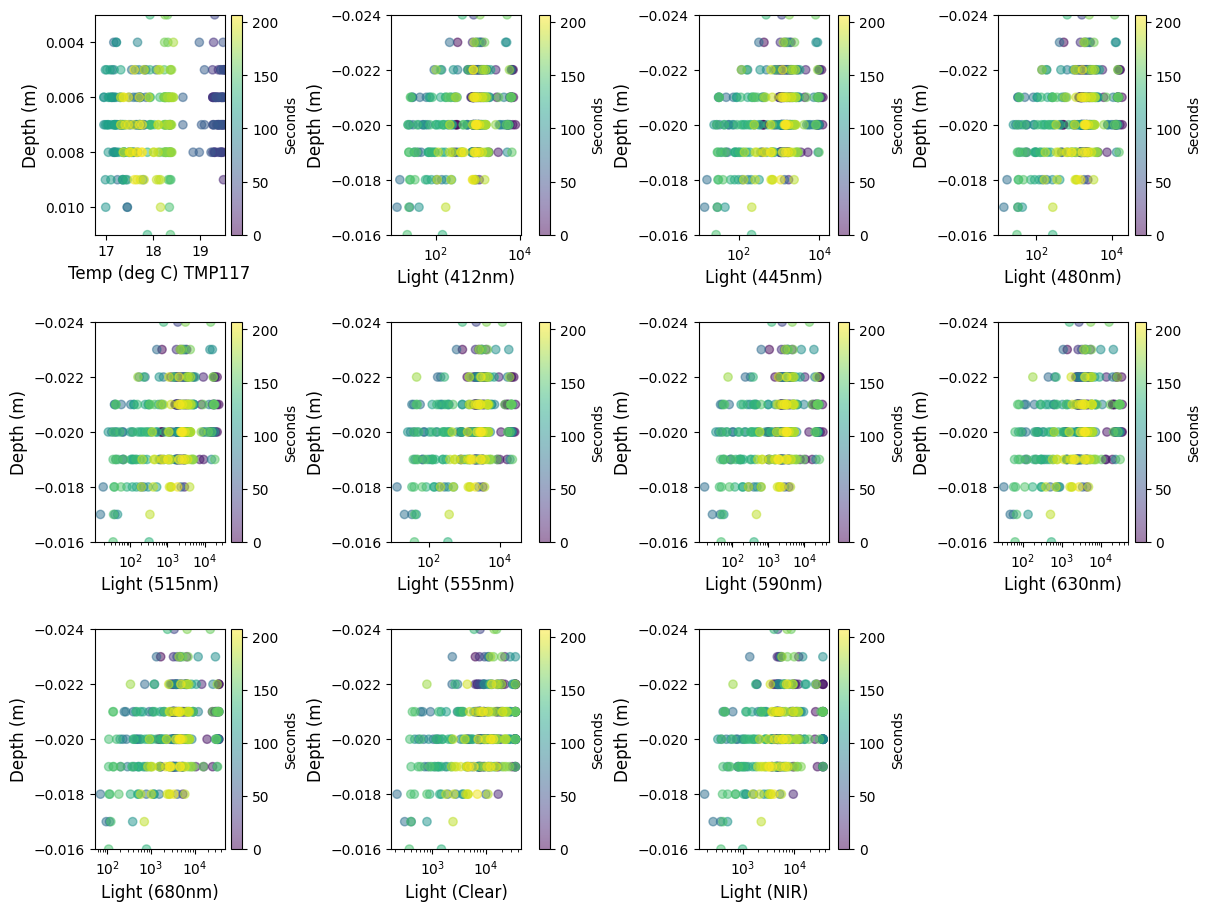

In [2]:
# Programs and functions
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import datetime
import linecache
import re
import os
from matplotlib import pyplot as plt 

# Bayley Johnsons Google Drive logic imports
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive

# google drive authenticate
gauth = GoogleAuth()
gauth.LocalWebserverAuth()

drive = GoogleDrive(gauth)

# folder ID for finding the files. DO NOT CHANGE THIS UNLESS YOU KNOW WHAT YOU ARE DOING
folder_id = "1Sjr8YaK8SRtL8ddeU2fYvt92v8jPAQPvhEt0MO8ee8ZknCAqwr1BVy18Z3e1wbDwpY1dU2EA"

# retrieves the list of files from the drive
file_list = drive.ListFile({
    'q': f"'{folder_id}' in parents and trashed=false"
}).GetList()



#grabs the file from the folder. Change file name to when you are running tests on multiple files.
target_filename = "260129-01-A016.txt"

for file in file_list:

    if file['title'] == target_filename:

        gfile = drive.CreateFile({'id': file['id']})
        File_1 = file['title']

        gfile.GetContentFile(File_1)

        break

#Centre wavelengths for light sensor
Wavelength = [415,445,480,515,555,590,630,680]

#Extract from file: Secchi Depth (SD), Forel–Ule (FU), 
#pH, serial number of device (SN), latitude, longitude and date
SD        = linecache.getline(File_1, 1)
SD        = float(re.findall(r'\d+', SD)[0]) if re.findall(r'\d+', SD) else 0.0
FU        = linecache.getline(File_1, 2)
FU        = float(re.findall(r'\d+', FU)[0]) if re.findall(r'\d+', FU) else 0.0
pH        = linecache.getline(File_1, 3)
pH        = float(re.findall(r'\d+', pH)[0]) if re.findall(r'\d+', pH) else 0.0
SN        = linecache.getline(File_1, 4)
SN        = float(re.findall(r'\d+', SN)[0]) if re.findall(r'\d+', SN) else 0.0
Latitude  = linecache.getline(File_1, 5)
Latitude  = float(re.findall(r'-?\d+\.?\d+', Latitude)[0]) if re.findall(r'-?\d+\.?\d+', Latitude) else 0.0
Longitude = linecache.getline(File_1, 6)
Longitude = float(re.findall(r'-?\d+\.?\d+', Longitude)[0]) if re.findall(r'-?\d+\.?\d+', Longitude) else 0.0                      
Date      = linecache.getline(File_1, 7)
Date      = re.findall(r'\d+', Date)
Year      = float(Date[0]) if len(Date) > 0 else 0.0
Month     = float(Date[1]) if len(Date) > 1 else 0.0
Day       = float(Date[2]) if len(Date) > 2 else 0.0

# Extract profile data
df = pd.read_csv(File_1, header=7)
Time_SS           = df.loc[:,'Time (UTC)'].to_numpy()
Pressure_SS       = df.loc[:,' Pressure (mbar) MS5803'].to_numpy()
Temp_MS5803_SS    = df.loc[:,' Temp (deg C) MS5803'].to_numpy()
E415nm_SS         = df.loc[:,' ED 415nm'].to_numpy()
E445nm_SS         = df.loc[:,' ED 445nm'].to_numpy()
E480nm_SS         = df.loc[:,' ED 480nm'].to_numpy()
E515nm_SS         = df.loc[:,' ED 515nm'].to_numpy()
E555nm_SS         = df.loc[:,' ED 555nm'].to_numpy()
E590nm_SS         = df.loc[:,' ED 590nm'].to_numpy()
E630nm_SS         = df.loc[:,' ED 630nm'].to_numpy()
E680nm_SS         = df.loc[:,' ED 680nm'].to_numpy()
EPAR_SS           = df.loc[:,' ED Clear'].to_numpy()
ENIR_SS           = df.loc[:,' ED NIR'].to_numpy()
Temp_TH_SS        = df.loc[:,' Temp (deg C) TMP117'].to_numpy()

#Compute atmospheric pressure assuming first 5 readings are in atmosphere
ATMOS_P           = np.median(Pressure_SS[0:5])

#Correct differences in sensor distance
#Compute depth (assuming pressure = depth)
Depth_SS          = ((Pressure_SS - ATMOS_P)/100.)
#Correct for distance between temperature sensor and pressure
Depth_SS_T        = Depth_SS + 0.007
#Correct for distance between light sensor and pressure
Depth_SS_L        = Depth_SS - 0.02
      
#Sort time to decimal hour and compute seconds (DATA_SEC) and second since start (DATA_SEC0)
HH = np.empty([len(Time_SS)])
MM = np.empty([len(Time_SS)])
SS = np.empty([len(Time_SS)])
for j in range(len(Time_SS)): 
    time = datetime.datetime.strptime(Time_SS[j], '%H:%M:%S')
    HH[j] = time.hour
    MM[j] = time.minute
    SS[j] = time.second
DATA_SEC = (HH*3600.) + (MM*60.) + (SS)
DATA_SEC0         = DATA_SEC - DATA_SEC[0]

#Print extracted data
print('Year = ', Year)
print('Month = ', Month)
print('Day = ', Day)
print('Latitude (degs N) = ', Latitude)
print('Longitude (degs E) = ', Longitude)
print('Secchi depth (cm) = ', SD)
print('Forel Ule = ', FU)
print('pH = ', pH)

#Set up the plot
fig, ([ax1, ax2, ax3, ax4], [ax5, ax6, ax7, ax8], [ax9, ax10, ax11, ax12]) = plt.subplots(3,4,  figsize=(12,9), \
    constrained_layout=True, gridspec_kw={'hspace': 0.1})

#Plot temperature (TMP117) profile
im1 = ax1.scatter(Temp_TH_SS,Depth_SS_T, c = DATA_SEC0, marker='o', alpha = 0.5)
ax1.set_ylabel('Depth (m)', fontsize=12)
ax1.set_xlabel('Temp (deg C) TMP117', fontsize=12)
ax1.set_ylim([np.max(Depth_SS_T),np.min(Depth_SS_T)])
ax1.set_xlim([np.min(Temp_TH_SS)-0.2,np.percentile(Temp_TH_SS, 90)])
cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label("Seconds")

#Plot light at 415nm
im2 = ax2.scatter(E415nm_SS,Depth_SS_L, c = DATA_SEC0, marker='o', alpha = 0.5)
ax2.set_ylabel('Depth (m)', fontsize=12)
ax2.set_xlabel('Light (412nm)', fontsize=12)
ax2.set_ylim([np.max(Depth_SS_L),np.min(Depth_SS_L)])
ax2.set_xscale('log')
cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.set_label("Seconds")

#Plot light at 445nm
im3 = ax3.scatter(E445nm_SS,Depth_SS_L, c = DATA_SEC0, marker='o', alpha = 0.5)
ax3.set_ylabel('Depth (m)', fontsize=12)
ax3.set_xlabel('Light (445nm)', fontsize=12)
ax3.set_ylim([np.max(Depth_SS_L),np.min(Depth_SS_L)])
ax3.set_xscale('log')
cbar3 = fig.colorbar(im3, ax=ax3)
cbar3.set_label("Seconds")

#Plot light at 480nm
im4 = ax4.scatter(E480nm_SS,Depth_SS_L, c = DATA_SEC0, marker='o', alpha = 0.5)
ax4.set_ylabel('Depth (m)', fontsize=12)
ax4.set_xlabel('Light (480nm)', fontsize=12)
ax4.set_ylim([np.max(Depth_SS_L),np.min(Depth_SS_L)])
ax4.set_xscale('log')
cbar4 = fig.colorbar(im4, ax=ax4)
cbar4.set_label("Seconds")

#Plot light at 515nm
im5 = ax5.scatter(E515nm_SS,Depth_SS_L, c = DATA_SEC0, marker='o', alpha = 0.5)
ax5.set_ylabel('Depth (m)', fontsize=12)
ax5.set_xlabel('Light (515nm)', fontsize=12)
ax5.set_ylim([np.max(Depth_SS_L),np.min(Depth_SS_L)])
ax5.set_xscale('log')
cbar5 = fig.colorbar(im5, ax=ax5)
cbar5.set_label("Seconds")

#Plot light at 555nm
im6 = ax6.scatter(E555nm_SS,Depth_SS_L, c = DATA_SEC0, marker='o', alpha = 0.5)
ax6.set_ylabel('Depth (m)', fontsize=12)
ax6.set_xlabel('Light (555nm)', fontsize=12)
ax6.set_ylim([np.max(Depth_SS_L),np.min(Depth_SS_L)])
ax6.set_xscale('log')
cbar6 = fig.colorbar(im6, ax=ax6)
cbar6.set_label("Seconds")

#Plot light at 590nm
im7 = ax7.scatter(E590nm_SS,Depth_SS_L, c = DATA_SEC0, marker='o', alpha = 0.5)
ax7.set_ylabel('Depth (m)', fontsize=12)
ax7.set_xlabel('Light (590nm)', fontsize=12)
ax7.set_ylim([np.max(Depth_SS_L),np.min(Depth_SS_L)])
ax7.set_xscale('log')
cbar7 = fig.colorbar(im7, ax=ax7)
cbar7.set_label("Seconds")

#Plot light at 630nm
im8 = ax8.scatter(E630nm_SS,Depth_SS_L, c = DATA_SEC0, marker='o', alpha = 0.5)
ax8.set_ylabel('Depth (m)', fontsize=12)
ax8.set_xlabel('Light (630nm)', fontsize=12)
ax8.set_ylim([np.max(Depth_SS_L),np.min(Depth_SS_L)])
ax8.set_xscale('log')
cbar8 = fig.colorbar(im8, ax=ax8)
cbar8.set_label("Seconds")

#Plot light at 680nm
im9 = ax9.scatter(E680nm_SS,Depth_SS_L, c = DATA_SEC0, marker='o', alpha = 0.5)
ax9.set_ylabel('Depth (m)', fontsize=12)
ax9.set_xlabel('Light (680nm)', fontsize=12)
ax9.set_ylim([np.max(Depth_SS_L),np.min(Depth_SS_L)])
ax9.set_xscale('log')
cbar9 = fig.colorbar(im9, ax=ax9)
cbar9.set_label("Seconds")

#Plot light at Clear channel
im10 = ax10.scatter(EPAR_SS,Depth_SS_L, c = DATA_SEC0, marker='o', alpha = 0.5)
ax10.set_ylabel('Depth (m)', fontsize=12)
ax10.set_xlabel('Light (Clear)', fontsize=12)
ax10.set_ylim([np.max(Depth_SS_L),np.min(Depth_SS_L)])
ax10.set_xscale('log')
cbar10 = fig.colorbar(im10, ax=ax10)
cbar10.set_label("Seconds")

#Plot light at Clear channel
im11 = ax11.scatter(ENIR_SS,Depth_SS_L, c = DATA_SEC0, marker='o', alpha = 0.5)
ax11.set_ylabel('Depth (m)', fontsize=12)
ax11.set_xlabel('Light (NIR)', fontsize=12)
ax11.set_ylim([np.max(Depth_SS_L),np.min(Depth_SS_L)])
ax11.set_xscale('log')
cbar11 = fig.colorbar(im11, ax=ax11)
cbar11.set_label("Seconds")

ax12.set_visible(False)

plt.show()
os.remove(File_1)